In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
import joblib

SEED = 42

In [ ]:
# Automatically set the total number of cores available
num_cores = multiprocessing.cpu_count()
os.environ["OMP_NUM_THREADS"] = str(num_cores)
os.environ["MKL_NUM_THREADS"] = str(num_cores)
print(num_cores)
print(torch.version.cuda, torch.cuda.is_available(), torch.backends.cudnn.enabled)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

species = "Homo_sapiens"
species_space = species.replace("_", " ")

# Check if the directory exists
if not os.path.exists(species):
    os.makedirs(species)
    print(f"Directory '{species}' created.")
else:
    print(f"Directory '{species}' already exists.")

window_size = 400
window_abbr = "0.4"
print(f"window_size: {window_size}")
half_window_size = window_size // 2

# Filter for only placed sequences
chroms = list(range(1, 23)) + ['X', 'Y']
chrom_list = [f'chr{chrom}' for chrom in chroms]

subset_str = 'chromsplit'

40
13.0 False True
cpu
Directory 'Homo_sapiens' already exists.
window_size: 400


### Data pre-processing

In [ ]:
# source = 'hprc_HG00658'
source_id = "HG00658"

# source = 'hprc_HG01099'
source_id = "HG01099"

source = 'hprc_HG02027'
source_id = "HG02027"

data = pd.read_csv(f"{species}/{species}_{source}_balanced_data_{window_abbr}kb_annotated.csv")
print(f"data.shape: {data.shape}")

feature_cols = ['chrom', 'sequence', 'label', 'sv_type', 'sv_len', 'pos', 'end',
       'left_start', 'left_end', 'right_start', 'right_end', 'num_del',
       'num_ins', 'num_inv', 'num_smalldel', 'num_smallins', 'gc_content',
       'full_snp_count', 'distance_to_exon', 'distance_to_Alu/SINE',
       'distance_to_L1/LINE', 'distance_to_L2/LINE', 
       'distance_to_Low_complexity/Low_complexity', 'distance_to_MIR/SINE', 'distance_to_Satellite/Satellite',
       'distance_to_Simple_repeat/Simple_repeat',
       'avg_phyloP_scores', 'avg_recomb_rate_full', 'avg_cCRE_full',
       'avg_DNase_score_full', 'avg_tf_score_full']

balanced_data = data[feature_cols].copy()
balanced_data['num_ins_del'] = balanced_data['num_ins'] + balanced_data['num_del']
balanced_data['num_small_indel'] = balanced_data['num_smallins'] + balanced_data['num_smalldel']
balanced_data.drop(['num_ins', 'num_del', 'num_smallins', 'num_smalldel', 'left_end', 'right_start'], inplace=True, axis=1)

balanced_data.rename({
    'num_small_indel': 'Number of small indels',
    'num_ins_del': 'Number of large insertions and deletions',
    'num_inv': 'Number of inversions',
    'gc_content': 'GC content',
    'distance_to_Alu/SINE': 'Distance to nearest Alu/SINE',
    'distance_to_L1/LINE': 'Distance to nearest L1/LINE',
    'distance_to_L2/LINE': 'Distance to nearest L2/LINE',
    'distance_to_MIR/SINE': 'Distance to nearest MIR/SINE',
    'distance_to_Simple_repeat/Simple_repeat': 'Distance to nearest simple repeat',
    'distance_to_exon': 'Distance to nearest exon',
    'distance_to_Satellite/Satellite': 'Distance to nearest satellite',
    'distance_to_Low_complexity/Low_complexity': 'Distance to nearest low complexity repeat',
    'avg_phyloP_scores': 'Average phyloP score',
    'full_snp_count': 'Number of SNPs',
    'avg_DNase_score_full': 'Average DNase accessibility score',
    'avg_cCRE_full': 'Average cCRE score',
    'avg_tf_score_full': 'Average transcription factor peak',
    'avg_recomb_rate_full': 'Average recombination rate'
}, axis=1, inplace=True)

balanced_data

data.shape: (53780, 112)


,chrom,sequence,label,sv_type,sv_len,pos,end,left_start,right_end,Number of inversions,...,Distance to nearest MIR/SINE,Distance to nearest satellite,Distance to nearest simple repeat,Average phyloP score,Average recombination rate,Average cCRE score,Average DNase accessibility score,Average transcription factor peak,Number of large insertions and deletions,Number of small indels
0,chr4,ATCCCACCCCCACCATCACATCCATTGGTCACTGCTGTACAGTGGG...,0,nonSV,0,144619220,144619220,144619020,144619420,0,...,200,200,200,0.064390,6.643440e-07,0.0,83.5,38.000000,0,1
1,chr2,CCAGCCAAGCCAGCCAAGCCCGCCAACCAGCCAAGACAGGCATGCT...,1,INS,24348,90289009,90289010,90288809,90289210,0,...,200,200,0,-0.851333,6.814490e-06,0.0,0.0,0.000000,5,0
2,chr12,CTCCCTTTTCCATATATATATAGAGAGAGAGAGAAAGAGAGAGTAT...,1,DEL,304,37429831,37430135,37429631,37430335,0,...,200,200,0,-0.209830,1.922250e-02,0.0,0.0,0.000000,3,34
3,chr8,GAATTTCAAGACAAGGCCTTAGAAGTAATTGTAAAACTTTCTTATT...,0,nonSV,0,71718141,71718141,71717941,71718341,0,...,200,200,200,0.154902,7.939560e-01,0.0,0.0,0.000000,0,0
4,chr3,TTGTTCACGCAGACCTGAGTCCGGAGGCGCTCGCTGCACTTGGTAT...,1,INS,186,195059754,195059755,195059554,195059955,0,...,105,200,200,0.032322,3.225470e+00,0.0,69.0,47.553544,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53775,chr19,CGCCTTCGCCGCCGCCGCCGCAACCTCCAGCACCGCCGCCCCAGGC...,1,INS,22717,36307103,36307104,36306903,36307304,0,...,200,200,200,0.120885,8.928720e-08,0.0,0.0,0.000000,0,1
53776,chr18,GAAGCATTCTCAGAAACTTCTTTGGGATGTTTGCATTCATGTCACA...,0,nonSV,0,19322296,19322296,19322096,19322496,0,...,200,200,200,0.000000,1.323220e-03,0.0,0.0,0.000000,0,0
53777,chr10,GTCTTTCACTCAAATGTGGGTCAGAGCTAGGAAACATGCTATGATC...,0,nonSV,0,85011703,85011703,85011503,85011903,0,...,200,200,200,0.070107,2.171070e-19,0.0,0.0,0.000000,0,0
53778,chr1,GCTTATAGATACATATATAAATATATTTATTTATATTTATATATAA...,1,INS,481,101253578,101253579,101253378,101253779,0,...,200,200,0,-0.143235,7.283050e-06,0.0,0.0,0.000000,2,23


In [ ]:
mapping = {'A': [1, 0, 0, 0], 'T': [0, 1, 0, 0], 'C': [0, 0, 1, 0], 'G': [0, 0, 0, 1], 'N': [0, 0, 0, 0]}

def one_hot_encode(seq, mapping):
    return np.array([mapping[ch] for ch in seq])

def get_middle(seq):
    center = len(seq) // 2
    start = max(center - 500, 0)
    end = start + 1000
    return seq[start:end]

X_categorical = np.array([one_hot_encode(seq, mapping) for seq in balanced_data['sequence']])
y = balanced_data['label'].values
indices = np.arange(len(y))

num_feature_cols = ['Number of large insertions and deletions',
       'Number of small indels', 'Number of inversions', 'GC content',
       'Number of SNPs', 'Distance to nearest exon', 'Distance to nearest Alu/SINE',
       'Distance to nearest L1/LINE', 'Distance to nearest L2/LINE', 
       'Distance to nearest low complexity repeat', 'Distance to nearest MIR/SINE', 'Distance to nearest satellite',
       'Distance to nearest simple repeat',
       'Average phyloP score', 'Average recombination rate', 'Average cCRE score',
       'Average DNase accessibility score', 'Average transcription factor peak']

X_numerical = balanced_data[num_feature_cols].astype(float).to_numpy()
print(X_categorical.shape, X_numerical.shape, y.shape)

In [ ]:
test_chroms = ["chr13", "chr9", "chr10", "chr21", "chr17"]

# filter to OOD chromosomes only
ood_df = balanced_data[
    balanced_data["chrom"].isin(test_chroms)
].reset_index(drop=True).copy()

# prepare OOD dataset
X_categorical = np.array([
    one_hot_encode(seq, mapping)
    for seq in ood_df["sequence"]
])

y = ood_df["label"].values.astype(int)

X_numerical = (
    ood_df[num_feature_cols]
    .astype(float)
    .to_numpy()
)

# scale numerical features
scaler = joblib.load(f"{species}/{species}_{window_abbr}kb_scaler.pkl")
X_num_scaled = scaler.transform(X_numerical)

X_cat_tensor = torch.tensor(X_categorical, dtype=torch.float32).permute(0, 2, 1)
X_num_tensor = torch.tensor(X_numerical, dtype=torch.float32)

y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

ood_data = TensorDataset(X_cat_tensor, X_num_tensor, y_tensor)
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=False)

print("OOD chromosomes:", test_chroms)
print("ood_df:", ood_df.shape)
print("X_categorical:", X_categorical.shape)
print("X_numerical:", X_numerical.shape)
print("y:", y.shape)
print("label counts:", np.bincount(y))

OOD chromosomes: ['chr13', 'chr9', 'chr10', 'chr21', 'chr17']
ood_df: (9338, 27)
X_categorical: (9338, 400, 4)
X_numerical: (9338, 18)
y: (9338,)
label counts: [4339 4999]


In [73]:
n = 2
num_layers = f"{n}"
print(f"n: {num_layers}")

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=11, stride=stride, padding=5) 
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=11, stride=stride, padding=5)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = None

    def forward(self, x):
        residual = x
        if self.downsample:
            residual = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # out += residual
        out = out + residual
        out = self.relu(out)
        return out

class SV_CNN(nn.Module):
    def __init__(self, num_cat_channels, num_classes):
        super(SV_CNN, self).__init__()
        self.initial = nn.Sequential(
            nn.Conv1d(num_cat_channels, 128, kernel_size=1, stride=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=False)
        )

        self.layers = nn.ModuleList()
        self.layers.append(ResidualBlock(128, 128))
        for _ in range(n):  
            self.layers.append(ResidualBlock(128, 128))

        self.final_conv = nn.Conv1d(128, 32, kernel_size=1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
        self.fc1 = nn.Linear(12800, 128)
        self.fc2 = nn.Linear(128, num_classes)
        

    def forward(self, x_cat):
        x_cat = self.initial(x_cat)
        for layer in self.layers:
            x_cat = layer(x_cat)
        x_cat = self.final_conv(x_cat)
        
        x_cat = x_cat.view(x_cat.size(0), -1)  # Flatten the output
        x_cat = self.fc1(x_cat)
        x_cat = self.relu(x_cat)
        x_cat = self.fc2(x_cat)
        
        x = torch.sigmoid(x_cat)
        return x

    def extract_features(self, x_cat):
        x_cat = self.initial(x_cat)
        for layer in self.layers:
            x_cat = layer(x_cat)
        x_cat = self.final_conv(x_cat)
        x_cat = x_cat.view(x_cat.size(0), -1)
        x_cat = self.fc1(x_cat)
        x_cat = self.relu(x_cat)
        return x_cat 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SV_CNN(4, 1)
if torch.cuda.is_available():
    model.to(device)
print(device)
print(model)

model.load_state_dict(
    torch.load(
        f"{species}/{species}_{window_abbr}kb_best_model_{num_layers}_{subset_str}.pt",
        map_location=device
    )
)

model.eval()
rfc = joblib.load(f"{species}/{species}_{window_abbr}kb_rfc_with_cnn.pkl")

n: 2
cpu
SV_CNN(
  (initial): Sequential(
    (0): Conv1d(4, 128, kernel_size=(1,), stride=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (layers): ModuleList(
    (0-2): 3 x ResidualBlock(
      (conv1): Conv1d(128, 128, kernel_size=(11,), stride=(1,), padding=(5,))
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv1d(128, 128, kernel_size=(11,), stride=(1,), padding=(5,))
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (final_conv): Conv1d(128, 32, kernel_size=(1,), stride=(1,))
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=12800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
# CNN predictions + embeddings

cnn_probs = []
cnn_embeddings = []
y_true = []

with torch.no_grad():
    for X_cat, X_num, y_batch in ood_loader:
        X_cat = X_cat.to(device)

        probs = model(X_cat).detach().cpu().numpy().ravel()
        emb = model.extract_features(X_cat).detach().cpu().numpy()

        cnn_probs.extend(probs)
        cnn_embeddings.append(emb)
        y_true.extend(y_batch.numpy().ravel())

cnn_probs = np.array(cnn_probs)
cnn_embeddings = np.vstack(cnn_embeddings)
y_true = np.array(y_true).astype(int)

cnn_pred = (cnn_probs > 0.5).astype(int)

In [ ]:
# RF ensemble predictions

X_rf = np.hstack([
    X_numerical,
    cnn_probs.reshape(-1, 1)
])

rf_probs = rfc.predict_proba(X_rf)[:, 1]
rf_pred = (rf_probs > 0.5).astype(int)

len(cnn_pred), len(rf_pred)

(9338, 9338)

In [ ]:
# Metrics

def print_metrics(name, y_true, probs, pred):
    acc = accuracy_score(y_true, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0
    )

    auroc = roc_auc_score(y_true, probs)
    auprc = average_precision_score(y_true, probs)

    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"AUROC:     {auroc:.4f}")
    print(f"AUPRC:     {auprc:.4f}")

print_metrics("CNN", y_true, cnn_probs, cnn_pred)
print_metrics("RF ensemble", y_true, rf_probs, rf_pred)


CNN
Accuracy:  0.8045
Precision: 0.8795
Recall:    0.7355
F1:        0.8011
AUROC:     0.8702
AUPRC:     0.9068

RF ensemble
Accuracy:  0.8735
Precision: 0.9321
Recall:    0.8238
F1:        0.8746
AUROC:     0.9331
AUPRC:     0.9519


In [ ]:
def save_and_plot_roc_pr(y_true, y_pred_proba, model_name, color):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = average_precision_score(y_true, y_pred_proba)

    print(f"{model_name} roc_auc: {roc_auc:.4f}, pr_auc: {pr_auc:.4f}")

    roc_pr_data_file = (
        f"{species}/{species}_{window_abbr}kb_{source}_roc_pr_data_"
        f"{model_name}_{num_layers}_{subset_str}.npz"
    )

    np.savez(
        roc_pr_data_file,
        fpr=fpr,
        tpr=tpr,
        roc_auc=roc_auc,
        precision=precision,
        recall=recall,
        pr_auc=pr_auc
    )

    print(f"ROC/PR data saved for {model_name} to: {roc_pr_data_file}")

    return fpr, tpr, roc_auc, precision, recall, pr_auc

cnn_fpr, cnn_tpr, cnn_roc_auc, cnn_precision, cnn_recall, cnn_pr_auc = save_and_plot_roc_pr(
    y_true,
    cnn_probs,
    "CNN",
    "blue"
)

rf_fpr, rf_tpr, rf_roc_auc, rf_precision, rf_recall, rf_pr_auc = save_and_plot_roc_pr(
    y_true,
    rf_probs,
    "RF_ensemble",
    "orange"
)

CNN roc_auc: 0.8702, pr_auc: 0.9068
ROC/PR data saved for CNN to: Homo_sapiens/Homo_sapiens_0.4kb_hprc_HG02027_roc_pr_data_CNN_2_chromsplit.npz
RF_ensemble roc_auc: 0.9331, pr_auc: 0.9519
ROC/PR data saved for RF_ensemble to: Homo_sapiens/Homo_sapiens_0.4kb_hprc_HG02027_roc_pr_data_RF_ensemble_2_chromsplit.npz


ROC curve saved to: Homo_sapiens/Homo_sapiens_0.4kb_hprc_HG02027_roc_curve_CNN_RF_2_chromsplit.png


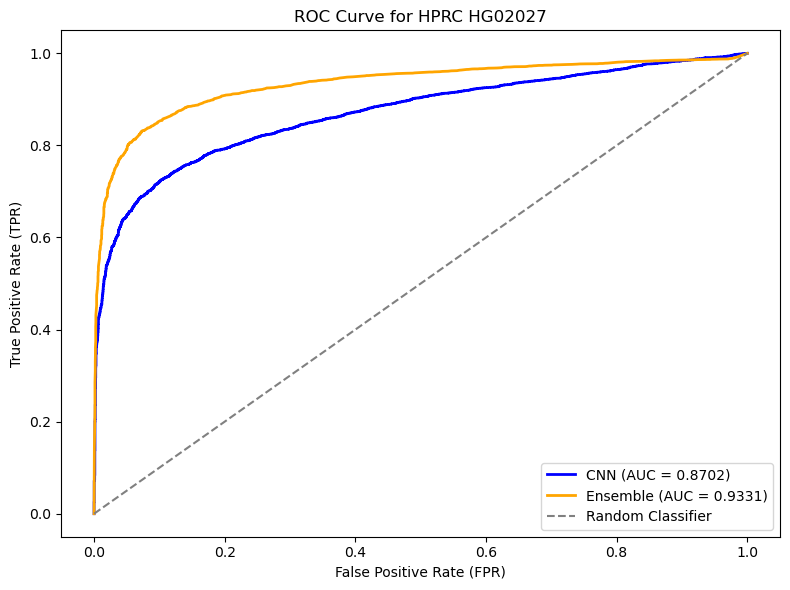

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    cnn_fpr,
    cnn_tpr,
    color="blue",
    lw=2,
    label=f"CNN (AUC = {cnn_roc_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    color="orange",
    lw=2,
    label=f"Ensemble (AUC = {rf_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title(f"ROC Curve for HPRC {source_id}")
plt.legend(loc="lower right")
plt.tight_layout()

roc_file = f"{species}/{species}_{window_abbr}kb_{source}_roc_curve_CNN_RF_{num_layers}_{subset_str}.png"
plt.savefig(roc_file, dpi=300)

print(f"ROC curve saved to: {roc_file}")
plt.show()

PR curve saved to: Homo_sapiens/Homo_sapiens_0.4kb_hprc_HG02027_pr_curve_CNN_RF_2_chromsplit.png


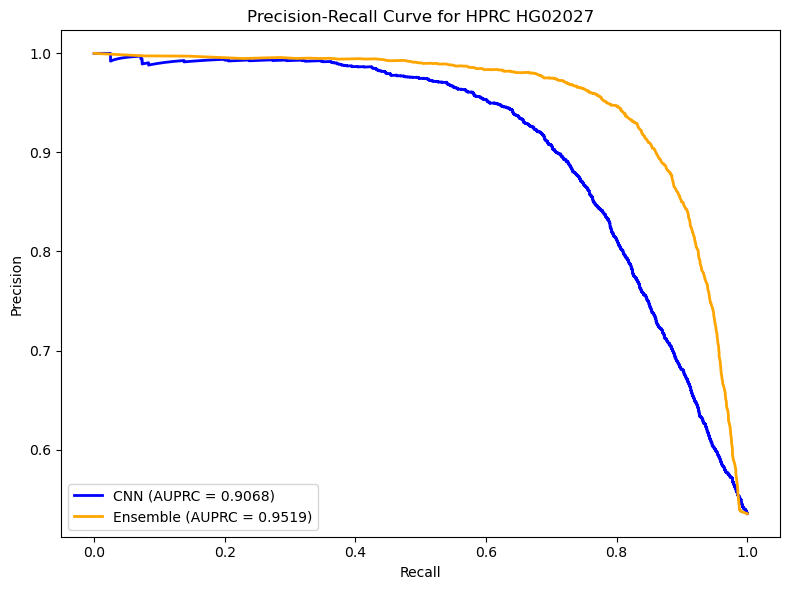

In [ ]:
baseline = np.mean(y_true)

plt.figure(figsize=(8, 6))
plt.plot(
    cnn_recall,
    cnn_precision,
    color="blue",
    lw=2,
    label=f"CNN (AUPRC = {cnn_pr_auc:.4f})"
)
plt.plot(
    rf_recall,
    rf_precision,
    color="orange",
    lw=2,
    label=f"Ensemble (AUPRC = {rf_pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve for HPRC {source_id}")
plt.legend(loc="lower left")
plt.tight_layout()

pr_file = f"{species}/{species}_{window_abbr}kb_{source}_pr_curve_CNN_RF_{num_layers}_{subset_str}.png"
plt.savefig(pr_file, dpi=300)
print(f"PR curve saved to: {pr_file}")
plt.show()

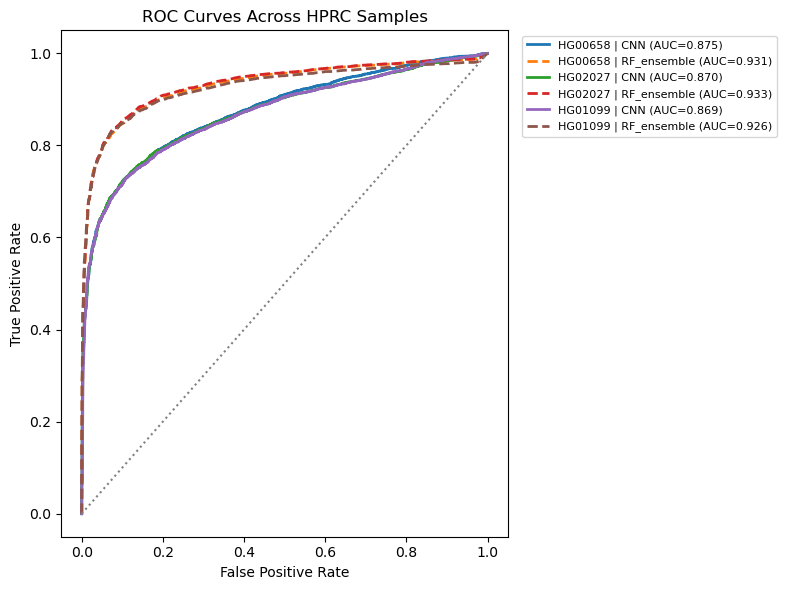

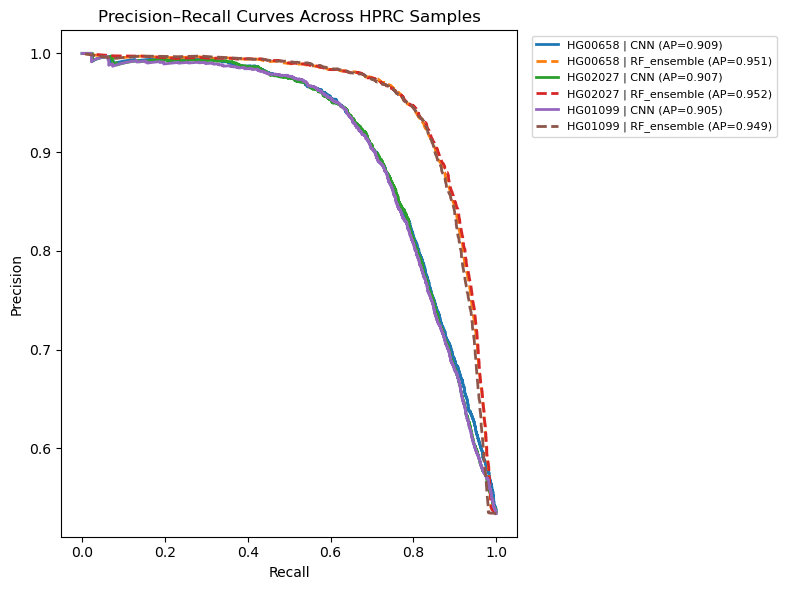

In [ ]:
sources = [
    "hprc_HG00658",
    "hprc_HG02027",
    "hprc_HG01099"
]

models = {
    "CNN": "-",
    "RF_ensemble": "--"
}

plt.figure(figsize=(8, 6))

for source in sources:
    for model, linestyle in models.items():
        data = np.load(
            f"{species}/{species}_{window_abbr}kb_{source}_"
            f"roc_pr_data_{model}_{num_layers}_{subset_str}.npz"
        )

        plt.plot(
            data["fpr"],
            data["tpr"],
            linestyle=linestyle,
            linewidth=2,
            label=(
                f"{source.replace('hprc_', '')} | "
                f"{model} "
                f"(AUC={data['roc_auc']:.3f})"
            )
        )

plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
    linewidth=1.5
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Across HPRC Samples")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_hprc_combined_roc_curve_{subset_str}.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 6))

for source in sources:
    for model, linestyle in models.items():
        data = np.load(
            f"{species}/{species}_{window_abbr}kb_{source}_"
            f"roc_pr_data_{model}_{num_layers}_{subset_str}.npz"
        )

        plt.plot(
            data["recall"],
            data["precision"],
            linestyle=linestyle,
            linewidth=2,
            label=(
                f"{source.replace('hprc_', '')} | "
                f"{model} "
                f"(AP={data['pr_auc']:.3f})"
            )
        )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves Across HPRC Samples")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.savefig(f"{species}/{species}_{window_abbr}kb_hprc_combined_pr_curve_{subset_str}.png", dpi=300)
plt.show()